Index(['timestamp', 'holiday', 'tavg', 'tmin', 'tmax', 'prcp_x', 'snow',
       'wspd_x', 'wpgt_x', 'pres_x', 'temp', 'dwpt', 'rhum', 'prcp_y',
       'wspd_y', 'wpgt_y', 'pres_y', 'tsun', 'event_name', 'market_day',
       'special_friday', 'value'],
      dtype='object')
1898 935
(1729, 168) (1729,)
(766, 168) (766,)
Epoch 1/100


/Users/vroni/miniconda3/envs/ParkData/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 - 10s - 196ms/step - loss: 0.0465 - val_loss: 0.0267
Epoch 2/100
49/49 - 6s - 129ms/step - loss: 0.0217 - val_loss: 0.0248
Epoch 3/100
49/49 - 6s - 124ms/step - loss: 0.0188 - val_loss: 0.0203
Epoch 4/100
49/49 - 7s - 133ms/step - loss: 0.0166 - val_loss: 0.0180
Epoch 5/100
49/49 - 6s - 128ms/step - loss: 0.0139 - val_loss: 0.0145
Epoch 6/100
49/49 - 6s - 124ms/step - loss: 0.0119 - val_loss: 0.0115
Epoch 7/100
49/49 - 6s - 125ms/step - loss: 0.0100 - val_loss: 0.0088
Epoch 8/100
49/49 - 6s - 130ms/step - loss: 0.0085 - val_loss: 0.0069
Epoch 9/100
49/49 - 7s - 136ms/step - loss: 0.0069 - val_loss: 0.0056
Epoch 10/100
49/49 - 6s - 128ms/step - loss: 0.0059 - val_loss: 0.0051
Epoch 11/100
49/49 - 6s - 126ms/step - loss: 0.0051 - val_loss: 0.0042
Epoch 12/100
49/49 - 7s - 139ms/step - loss: 0.0052 - val_loss: 0.0040
Epoch 13/100
49/49 - 8s - 157ms/step - loss: 0.0048 - val_loss: 0.0035
Epoch 14/100
49/49 - 8s - 163ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 15/100
49/49 - 8s - 

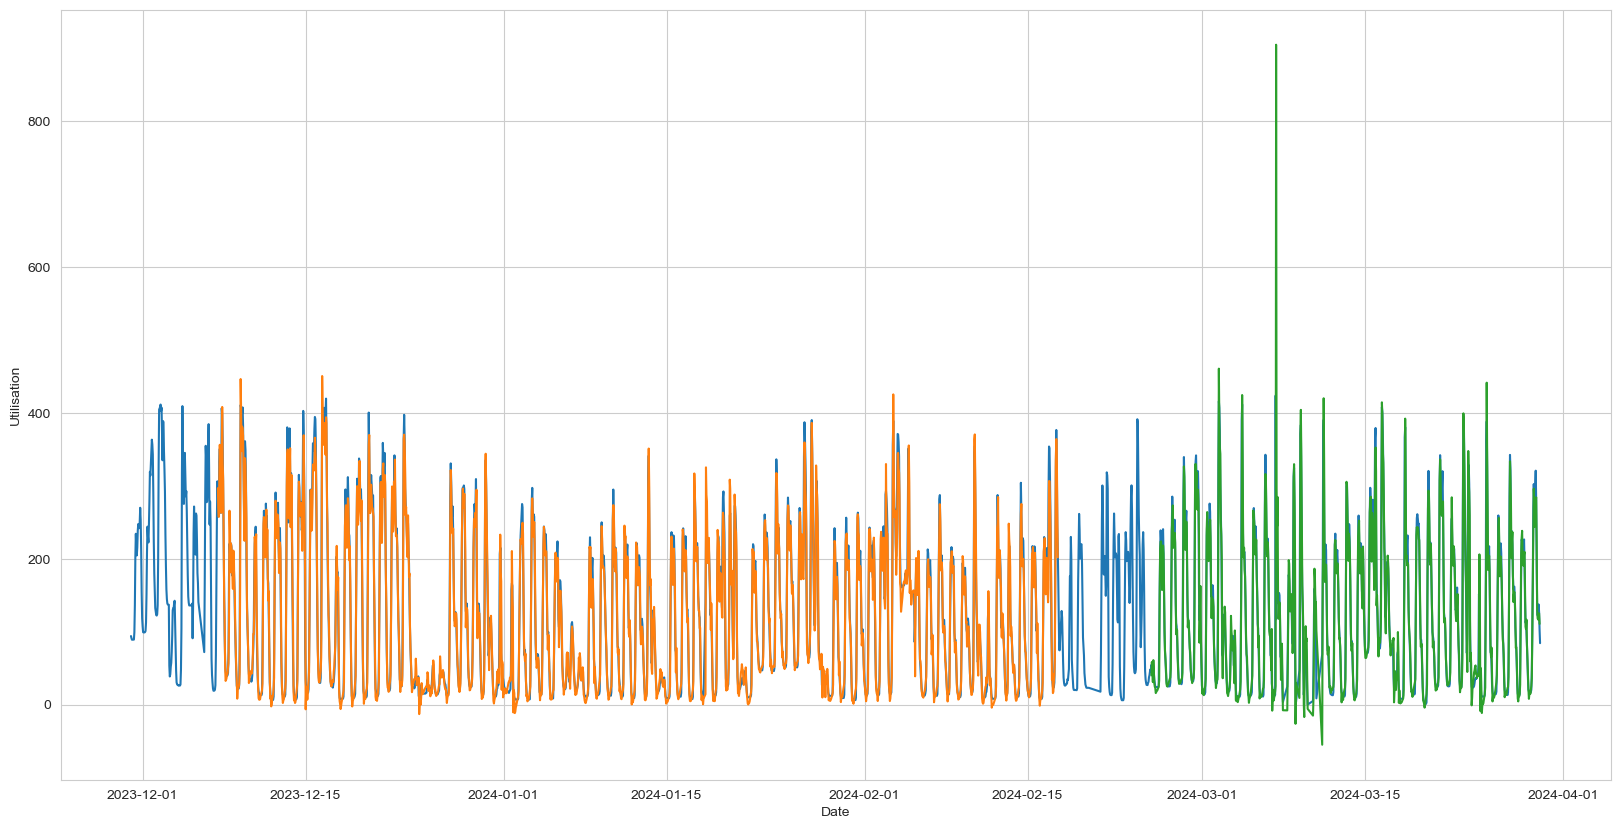

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# convert an array of values into a dataset matrix
def create_dataset(dataset, window=168):
	dataX = []
	dataY = []
	for i in range(len(dataset)-window-1):
		dataX.append(dataset[i:(i+window), 0])
		dataY.append(dataset[i + window, 0])
	return np.array(dataX), np.array(dataY)

tf.random.set_seed(7)
data = pd.read_csv('./data/out_hourly.csv')
df = pd.DataFrame(data)
df = df.sort_values('timestamp')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.columns)
start_date = pd.to_datetime('2023-11-30')
end_date = pd.to_datetime('2024-03-30')
df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

dataset_with_date = pd.DataFrame(df['value'], df['timestamp'])
dataset = pd.DataFrame(df['value'])
#dataset_with_date.set_index('timestamp', inplace=True)

#dataset = np.array(dataset)
dataset = dataset.astype('float32')
#LSTMs verwenden intern Aktivierungsfunktionen wie sigmoid und tanh:
#sigmoid: gibt Werte zwischen 0 und 1 aus
#tanh: gibt Werte zwischen -1 und 1 aus
#Diese großen Zahlen können die LSTM-Neuronen "überlasten" - sie arbeiten am besten mit kleinen Zahlen zwischen 0 und 1.
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
dates_train = dataset_with_date.iloc[0:train_size]
dates_test = dataset_with_date.iloc[train_size:]

# reshape into X=t and Y=t+1
print(len(train), len(test))
window = 168
trainX, trainY = create_dataset(train, window)
testX, testY = create_dataset(test, window)

print(trainX.shape, trainY.shape)
print(testX.shape, testY.shape)

# reshape input to be [samples, time steps, features]
#trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
#testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
# reshape input to be [samples, time steps, features]
#samples: Anzahl Trainingsbeispiele
#time steps: Länge der Zeitsequenz
#features: Anzahl Merkmale pro Zeitpunkt
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(trainX.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=32, verbose=2, validation_split=0.1)

# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# invert predictions
#invert the predictions before calculating error scores to ensure that performance is reported in the same units as the original data
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
print(np.isnan(trainY).any())
print(np.isnan(trainPredict).any())
# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

#shift the predictions so that they align on the x-axis with the original dataset. Once prepared, the data is plotted, showing the original dataset in blue, the predictions for the training dataset in green, and the predictions on the unseen test dataset in red
# shift train predictions for plotting
#Nach der Vorhersage musst du zurück-transformieren:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[window:len(trainPredict)+window, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(window*2)+1:len(dataset)-1, :] = testPredict

print(len(dates_train), len(dates_test), len(dataset_with_date), len(trainPredictPlot), len(testPredictPlot))

# plot baseline and predictions
plt.figure(figsize=(20, 10))
plt.plot(dataset_with_date.index, scaler.inverse_transform(dataset), label='Original Data')
plt.plot(dataset_with_date.index, trainPredictPlot, label='Training Predictions')
plt.plot(dataset_with_date.index, testPredictPlot, label='Test Predictions')
plt.xlabel('Date')
plt.ylabel('Utilisation')
plt.show()

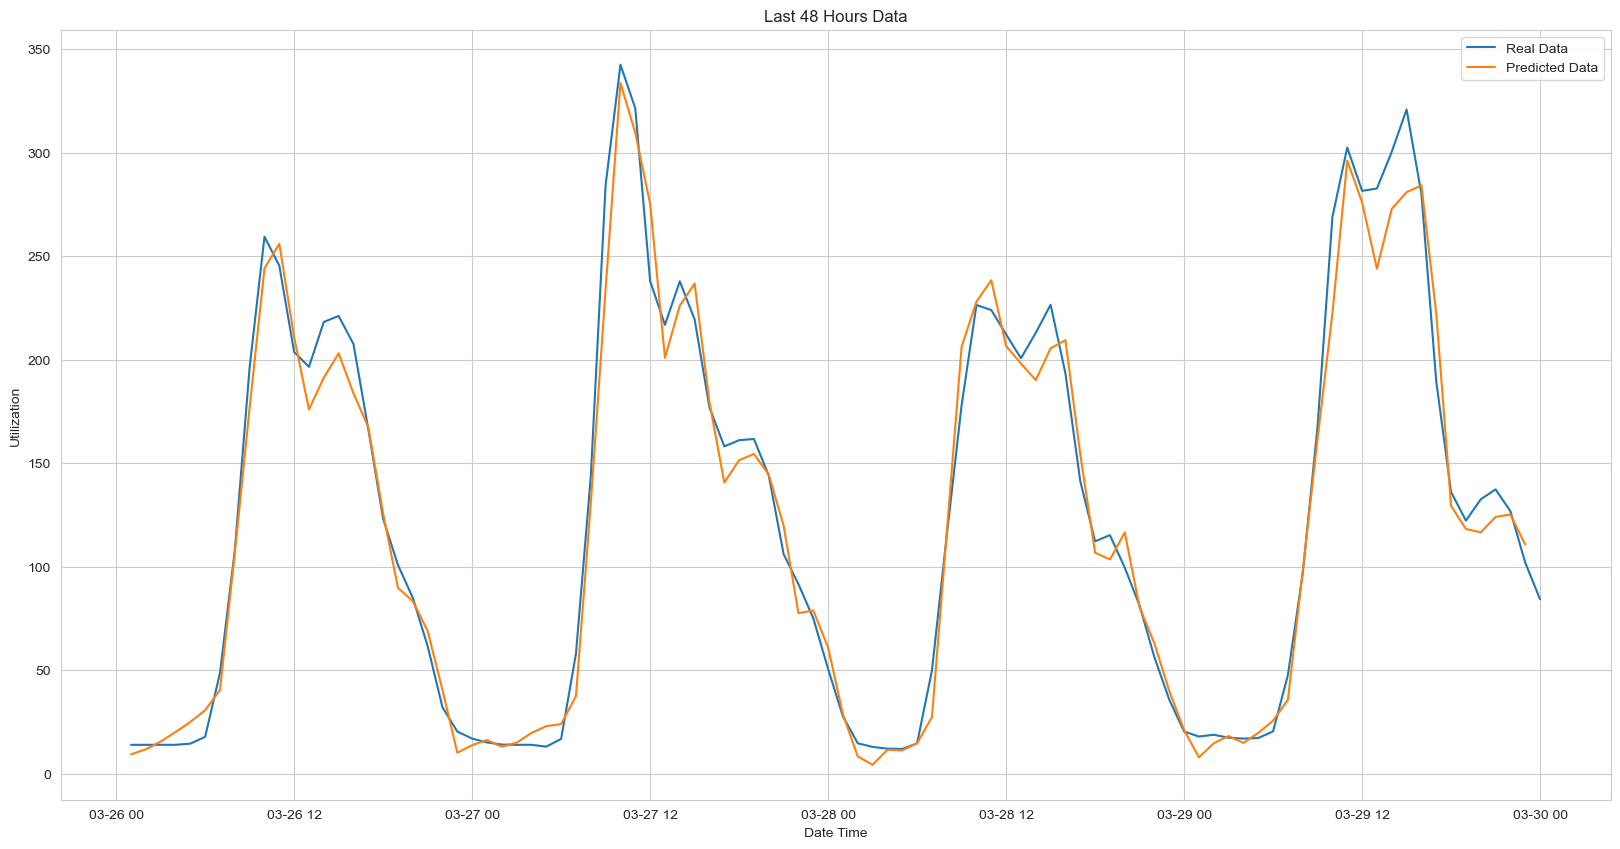

In [81]:
last_48 = testPredictPlot[-96:]
last_48_dates = dataset_with_date.tail(96)
last_48_dataset = dataset[-96:]

plt.figure(figsize=(20, 10))
plt.plot(last_48_dates.index, scaler.inverse_transform(last_48_dataset), label='Real Data')
plt.plot(last_48_dates.index, last_48, label='Predicted Data')
plt.xlabel('Date Time')
plt.ylabel('Utilization')
plt.title('Last 48 Hours Data')
plt.legend()
plt.show()

In [46]:
print(trainX.shape[0])

1729
